## Module 4: *(Template)*

**RENAME THE FILE TO INCLUDE YOUR COMPANY, GROUP NUMBER, AND LAST NAMES**

**E.G. KAMEN1_GROVES_MODULE_4.IPYNB**

## Team Members:
Esther Akinade & Cary Worrall
## Project Title:
Predictions of Ebola Cases: Sierra Leone 2014



## Project Goal:
This project aims to predict possible future Ebola cases during the 2014 epidemic in Sierra Leone using the cumulative SIR model and Euler’s method. 

## Disease Background:

Using your assigned disease, fill in the following bullet points. 
Ebola in Sierra Leone 

* Prevalence & incidence
Between the years of 2014 to 2016, West African had an high incidence of cases, over 28,000 total cases were reported and 11,300 deaths. In Sierra Leone ther were a total of 17,318 cases of ebola virus dieases. There was also a total of 2536 deaths and 886 recoveries that were reported. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC5528867/#:~:text=RESULTS,female%20cases%20(Table%201)
https://pmc.ncbi.nlm.nih.gov/articles/PMC4930947/

* Economic burden
The ebola epidemic had devasting impact on the economic burden on Guinea, Liberia, and Sierra Leone. There was an estimated $2.2 billion lost in the gross domestic product of the three countries. Additionally, it lowered investment and was a big loss in private sector. There was a loss in the agricultural production with led to food security and there was a restirction on moving goods across the border. In Sierra Leone, there was a deficit of about 3.10% of the GDP and the government budget averaged -4.46% of the GDP.
https://pmc.ncbi.nlm.nih.gov/articles/PMC7123237/#:~:text=The%20Ebola%20epidemic%20had%20a,1999%20(World%20Bank%202016).

* Risk factors (genetic, lifestyle) & Societal determinants
According to the "Host genetic Diversity" study, it indicates that genetic backgronds determine if a person is susceptiable to Ebola and it also determines the severity of the disease. Some lifestyle risk factors include contact with infcted fluids (blood, urine, feces, saliva, etc.) of infected person or animal. This can come from handling and butchering animals and caregiving of an infected person. Additionally, living or traveling in the infected areas where Ebola is prevalent high. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC4241145/
https://www.cdc.gov/ebola/about/index.html#:~:text=Risk%20factors,Reading%20How%20Ebola%20Disease%20Spreads

* Symptoms
The symptoms of the ebola disease are possible appear 2 to 21 days after contact, and on average, people show symptoms 8 to 10 days after exposure. Some dry symptoms include fever, aches and pains in the muscles and joint, serve headaches, weakness and fatigue, and sore throat. Later,"wet", symptoms, 4-5 days of the illness include loss of appetite, unexplained bleeding, nausea, abdominal pain, diarrha, and vomiting. Other symptoms include chest pain, shortness of breath, confusion, red eyes, skin rash, hiccups, and seizures. 
https://www.cdc.gov/ebola/signs-symptoms/index.html

* Diagnosis
Reverse transcription polymerase chain reaction (RT-PCR) is used in the case of diagnosing Ebola, which helps detect the virus's genetic material in the blood sample. Some other test include antibody and antigen test. The antibody test detects the patient's immune response to the virus, while the antigen test detects specific viral proteins. 
https://pmc.ncbi.nlm.nih.gov/articles/PMC9995846/#:~:text=Reverse%20transcription%E2%80%93polymerase%20chain%20reaction,be%20purified%20by%20extraction%20steps.
https://pmc.ncbi.nlm.nih.gov/articles/PMC5653233/#:~:text=Patient%20samples%20are%20tested%20either,2015

* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

Cell and Molecular Physiology: 
- Ebola enters cell by attachement and endocytosis
        - entry: viral glycoprotien(GP) binding to the host cell receptor, which triggering the cell to engulf the virus through macropinocytosis
        - inside the cell: the viral RNA is relased and replicated. The virus suppresses the host's immune response and causes cell and tissue damage 
        https://pmc.ncbi.nlm.nih.gov/articles/PMC4495366/#:~:text=Virus%20entry,and%20macropinocytosis%20(Figure%202).
Anatomy and Organ Physiology 
- Immune Suppression: ebola virus suppressing the host's immune response by preventing interferon production and signaling 
- Liver Damage: the virus destroys liver cells(hepatocytes), which leads to the leakage of liver enzymes into the blood, which inhibits the liver to clear the virus and produce clotting factors. 
- Vascular damage: the viral damage increases the permeability of blood vessels, leads to internal bleedinf and hemorrhaging 
- Kidney dsyfunction: the virus damages renal tubular cells and the glomerular epithelium leading to kidney function. 
https://www.abeomics.com/ebola-virus-pathogenesis#:~:text=During%20infection%2C%20monocytes%20/macrophages%20in,normally%20functions%20in%20cell%20communication.


## Dataset: 

*(Describe the data set you will analyze. Cite the source(s) of the data. Describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.)*

The data set that I will be analyzing Ebola cases is from Human Data by the World Health Organization. The data was collected from multiple locations, such as Italy, Liberia, Mali, Nigeria, Sierra Leone, and much more. The time period of the dataset is from August 29,2014 to March 23, 2016. 

         date  confirmed_cases
0  2014-08-29           1026.0
1  2014-09-05           1261.0
2  2014-09-08           1361.0
3  2014-09-12           1424.0
4  2014-09-16           1620.0
        date  confirmed_cases  new_cases     I_est  R_est  S_est
0 2014-08-29           1026.0     1026.0  0.001026    0.0    0.0
1 2014-09-05           1261.0      235.0  0.001261    0.0    0.0
2 2014-09-08           1361.0      100.0  0.001361    0.0    0.0
3 2014-09-12           1424.0       63.0  0.001424    0.0    0.0
4 2014-09-16           1620.0      196.0  0.001620    0.0    0.0


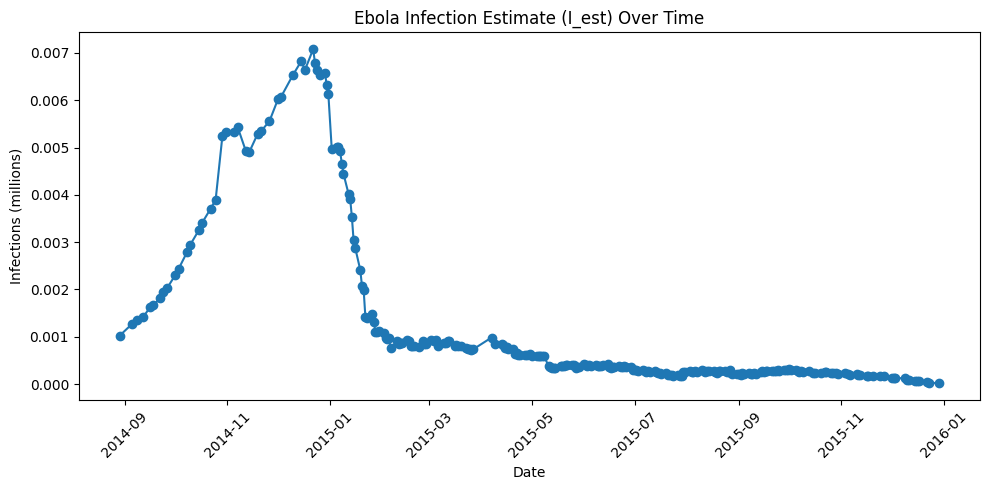

In [ ]:
from main_functions import convert_cumulative_to_SIR
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the Ebola Sierra Leone dataset
df = pd.read_csv("ebola_sierra_leone_data_2014_2015_cumulative.csv")
print(df.head())   # show first few rows

# Ensure date column is actual datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Convert cumulative cases to S, I, R estimates
N = 6876000 / 1e6   # population in millions

data_sir = convert_cumulative_to_SIR(
    df,
    date_col='date',
    cumulative_col='confirmed_cases',
    population=N,
    infectious_period=21,
    new_case_col='new_cases',
    I_col='I_est',
    R_col='R_est',
    S_col='S_est'
)

# Convert to millions for plotting
data_sir['I_est'] = data_sir['I_est'] / 1e6

print(data_sir.head())  # confirm values look correct

# 3. Plot S, I, R over time
plt.plot(data_sir['date'], data_sir['I_est'], marker='o')

plt.xlabel('Date')
plt.ylabel('Infections (millions)')
plt.title('Ebola Infection Estimate (I_est) Over Time')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Data Analyis: 

### Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

In [2]:
## PYTHON CODE TO BUILD AND FIT AN SIR MODEL GOES HERE. INTERSPERSE COMMENTS (IN MARKDOWN) TO EXPLAIN EACH STEP.

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*